In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#importing Data
df = pd.read_csv("gas_turbines.csv")

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15039 entries, 0 to 15038
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      15039 non-null  float64
 1   AP      15039 non-null  float64
 2   AH      15039 non-null  float64
 3   AFDP    15039 non-null  float64
 4   GTEP    15039 non-null  float64
 5   TIT     15039 non-null  float64
 6   TAT     15039 non-null  float64
 7   TEY     15039 non-null  float64
 8   CDP     15039 non-null  float64
 9   CO      15039 non-null  float64
 10  NOX     15039 non-null  float64
dtypes: float64(11)
memory usage: 1.3 MB


In [3]:
df.duplicated().sum()

0

In [4]:
df.describe()

,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
count,15039.000000,15039.00000,15039.000000,15039.000000,15039.000000,15039.000000,15039.000000,15039.000000,15039.000000,15039.000000,15039.000000
mean,17.764381,1013.19924,79.124174,4.200294,25.419061,1083.798770,545.396183,134.188464,12.102353,1.972499,68.190934
std,7.574323,6.41076,13.793439,0.760197,4.173916,16.527806,7.866803,15.829717,1.103196,2.222206,10.470586
min,0.522300,985.85000,30.344000,2.087400,17.878000,1000.800000,512.450000,100.170000,9.904400,0.000388,27.765000
25%,11.408000,1008.90000,69.750000,3.723900,23.294000,1079.600000,542.170000,127.985000,11.622000,0.858055,61.303500
50%,18.186000,1012.80000,82.266000,4.186200,25.082000,1088.700000,549.890000,133.780000,12.025000,1.390200,66.601000
75%,23.862500,1016.90000,90.043500,4.550900,27.184000,1096.000000,550.060000,140.895000,12.578000,2.160400,73.935500
max,34.929000,1034.20000,100.200000,7.610600,37.402000,1100.800000,550.610000,174.610000,15.081000,44.103000,119.890000


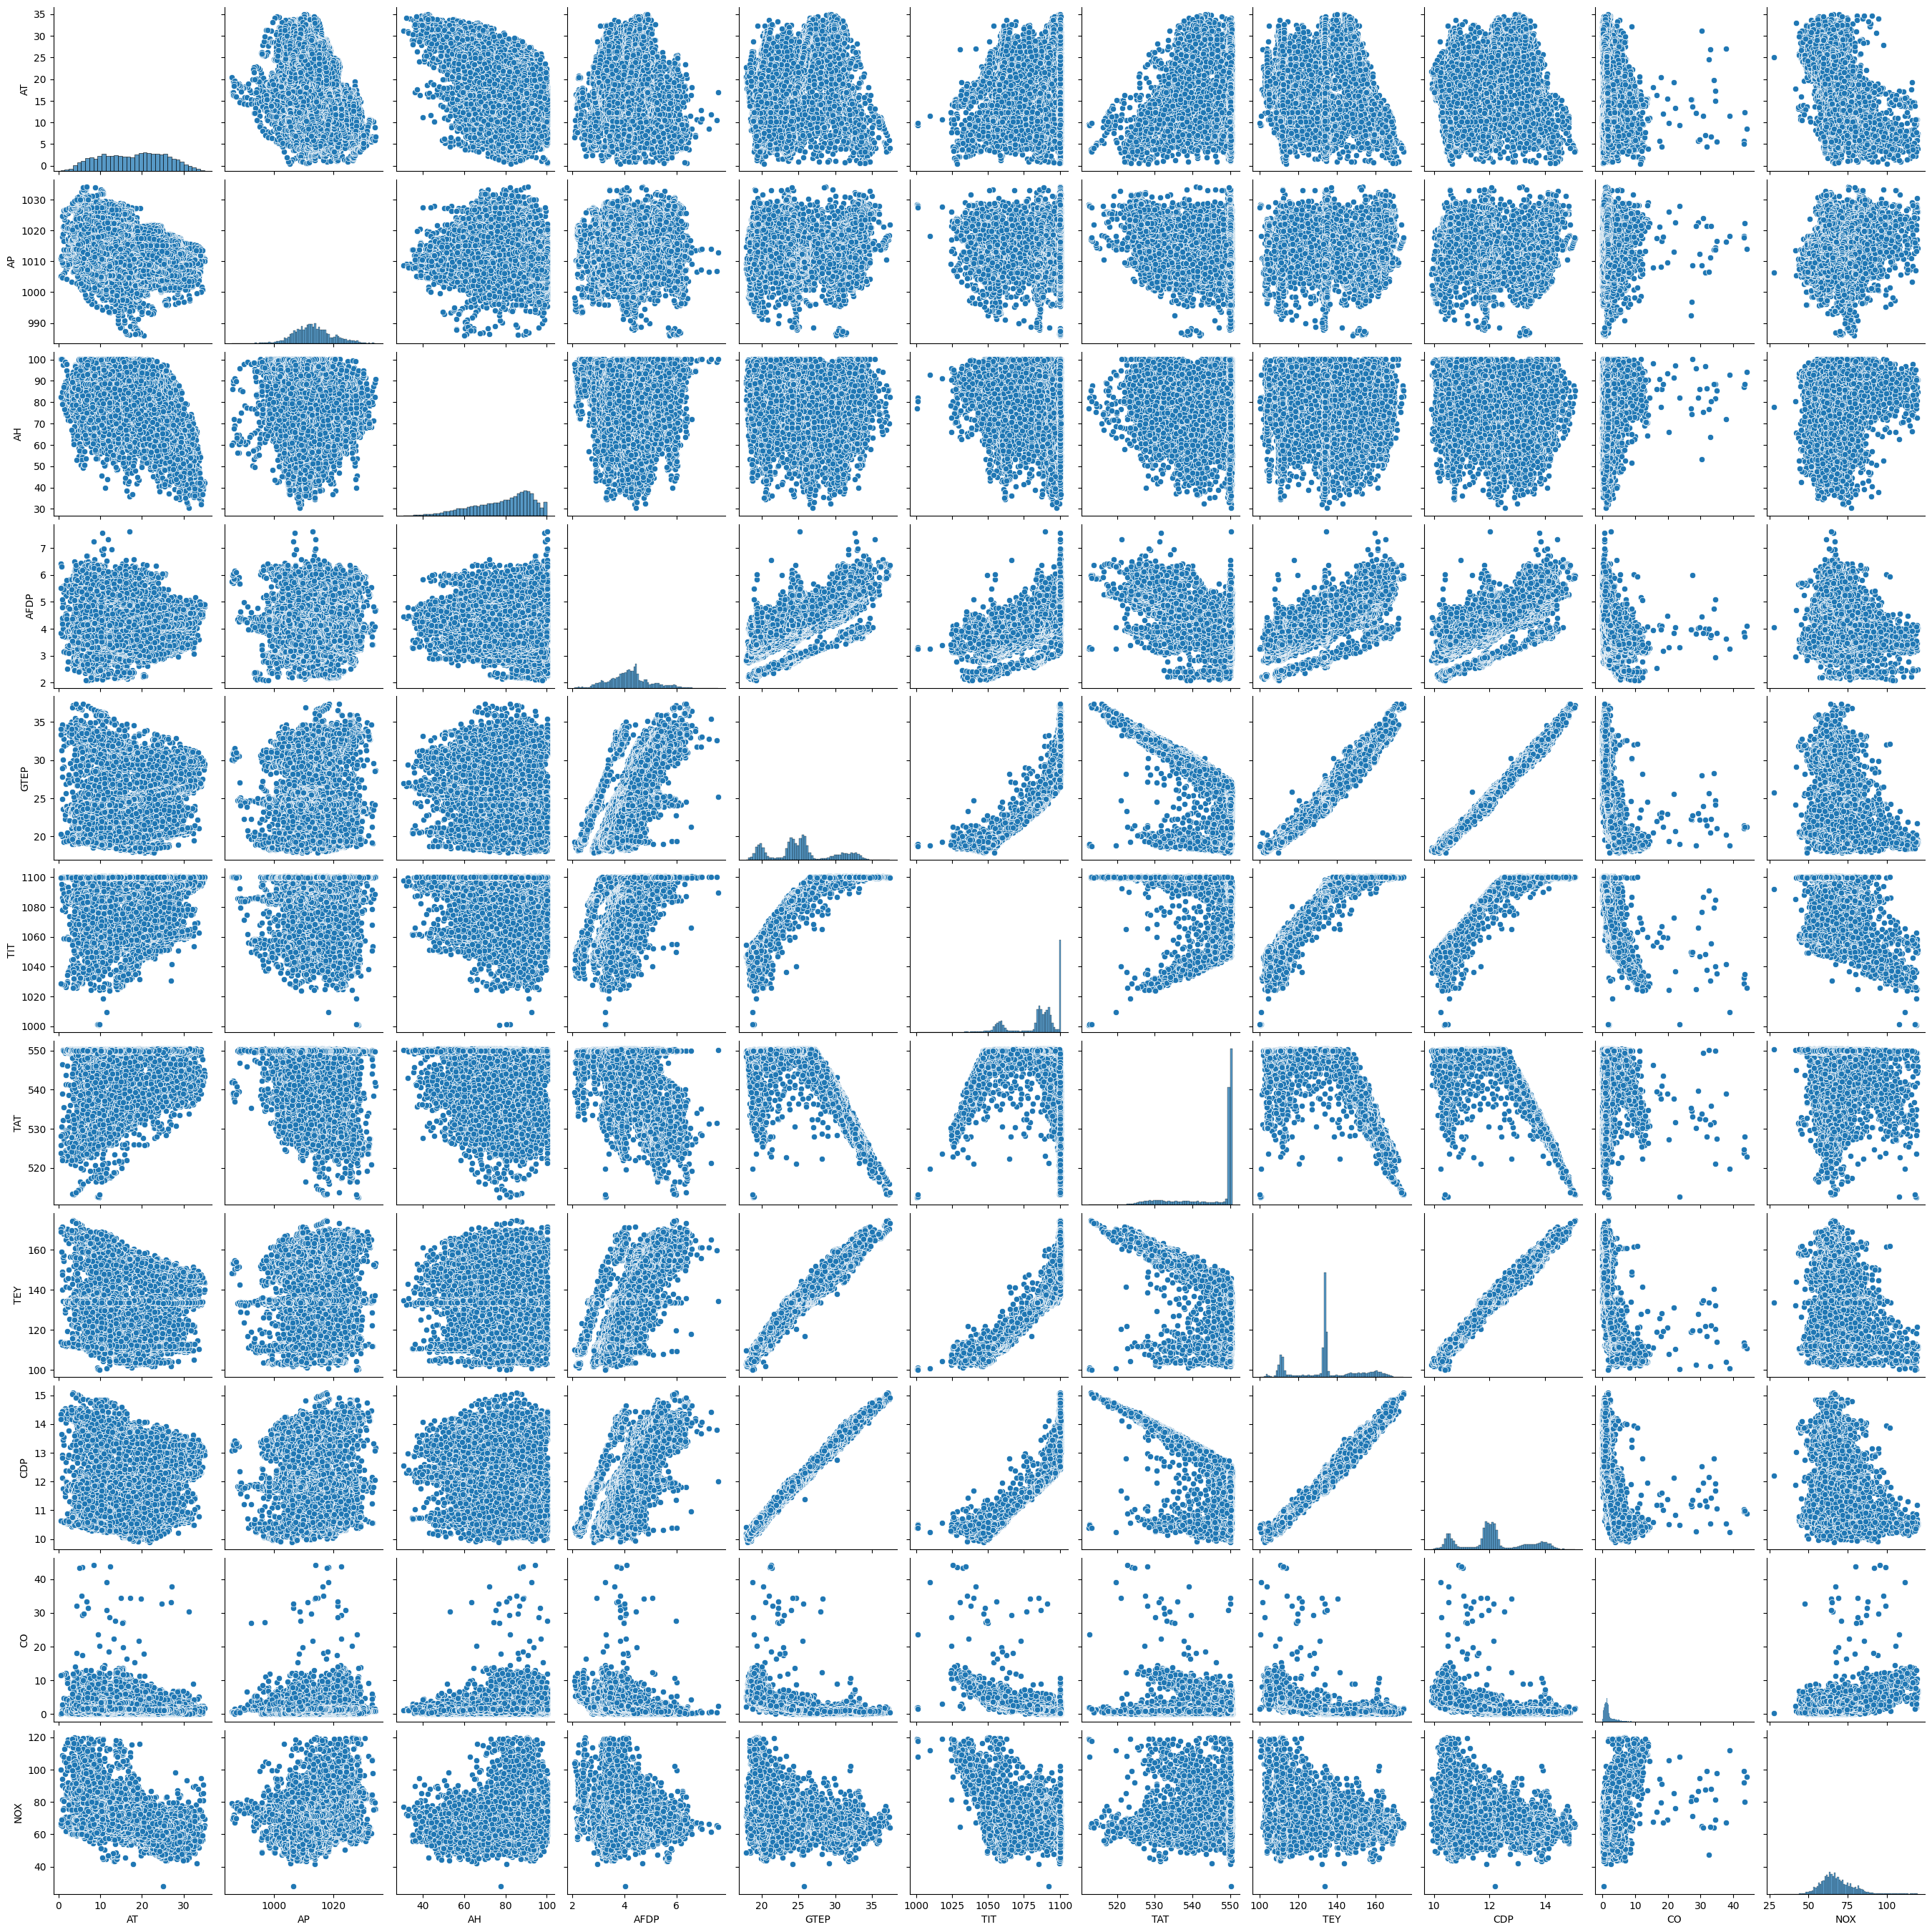

In [5]:
sns.pairplot(df)
plt.show()

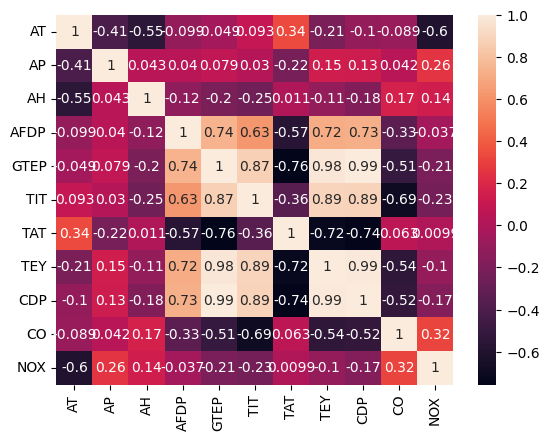

In [6]:
sns.heatmap(df.corr(), annot=True)
plt.show()

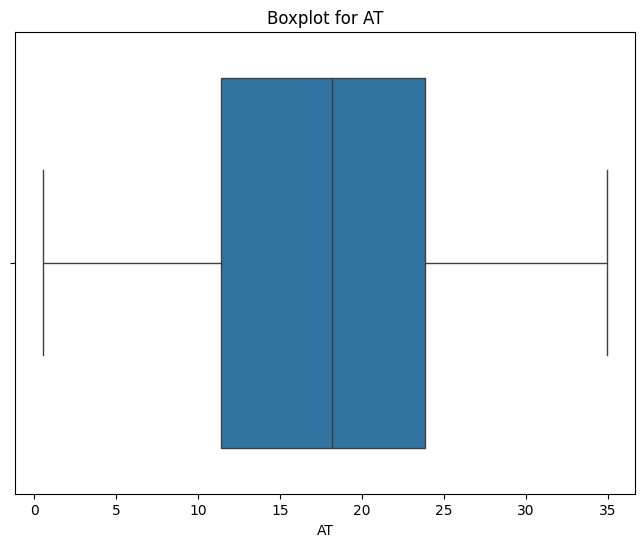

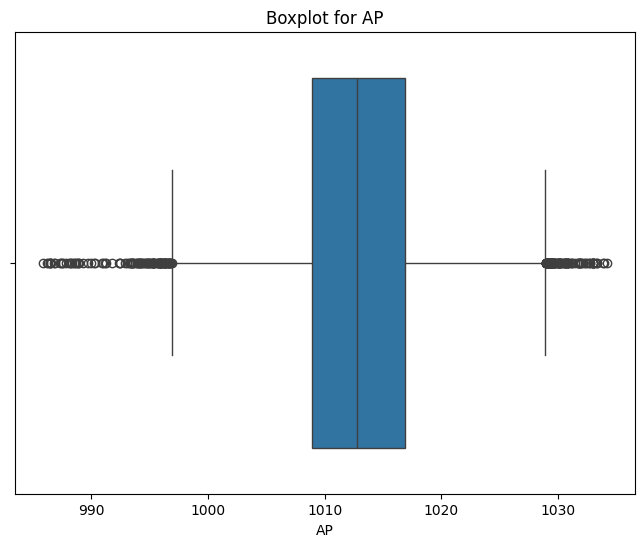

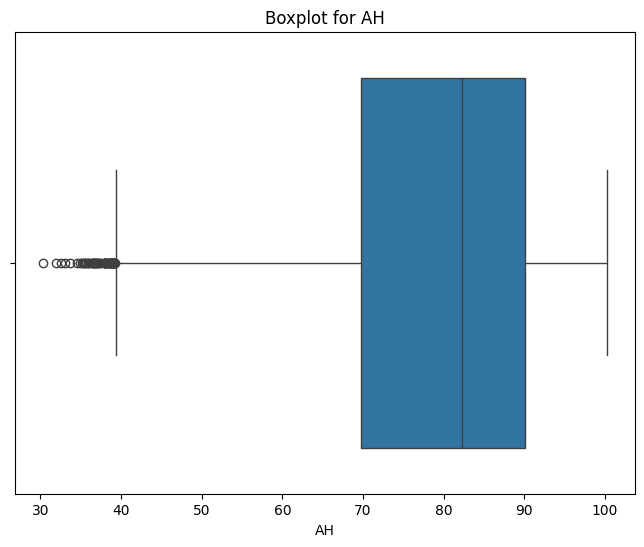

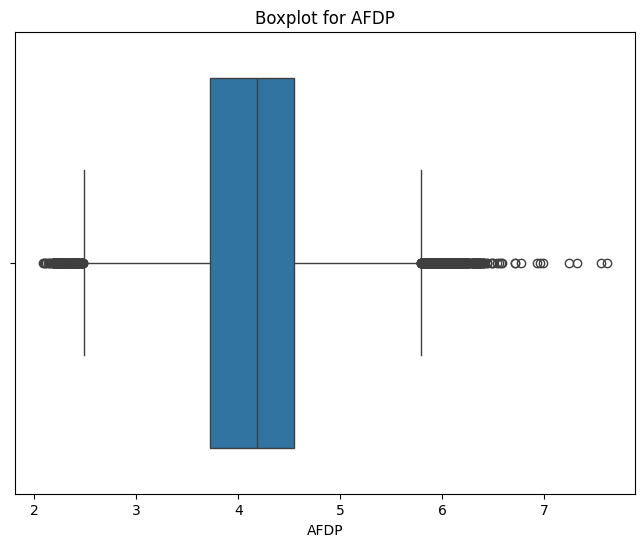

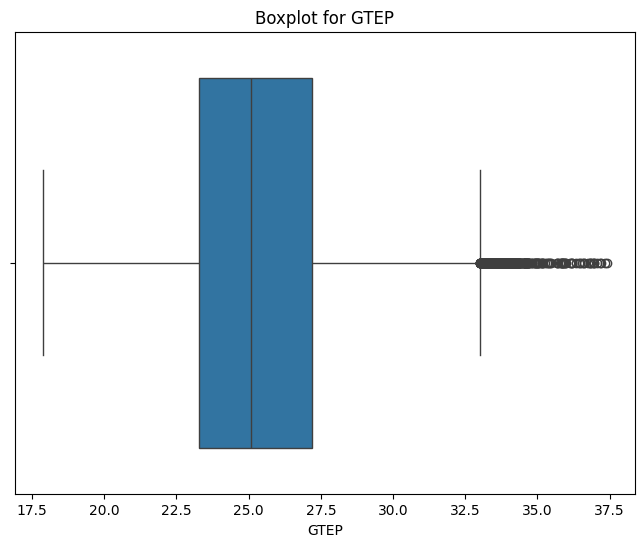

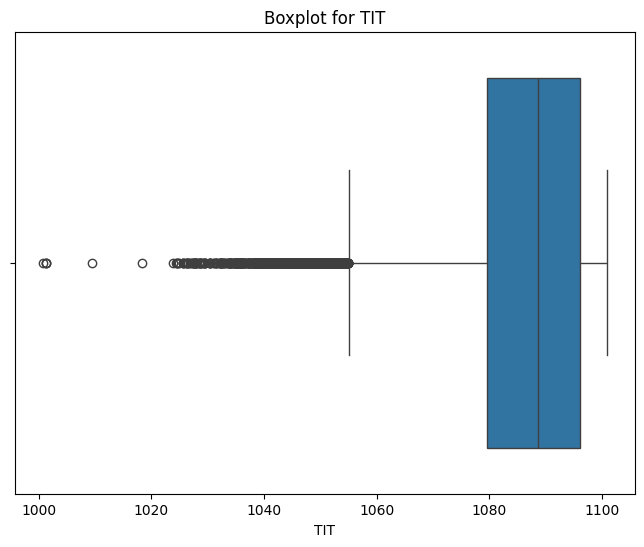

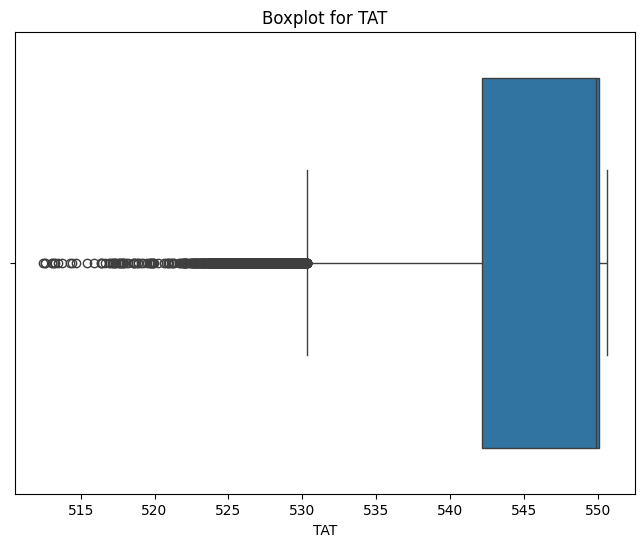

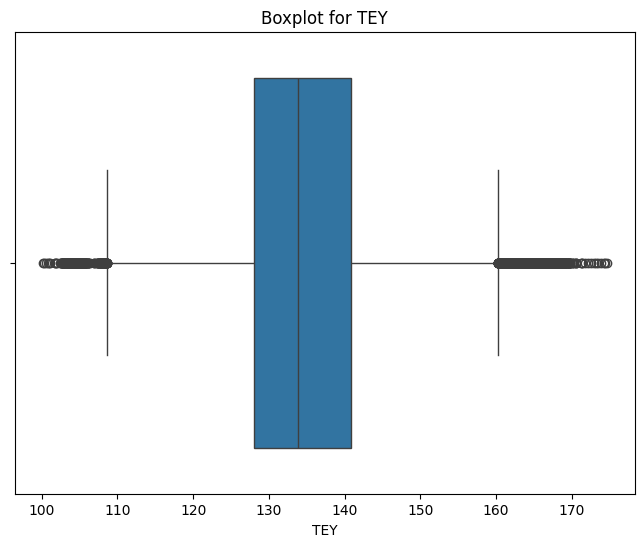

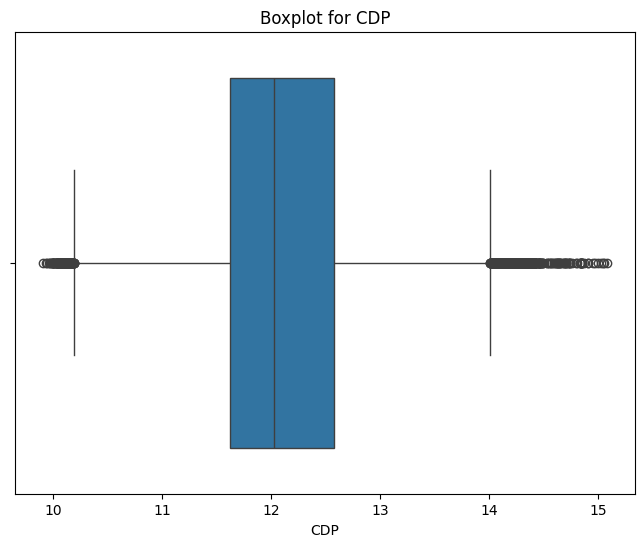

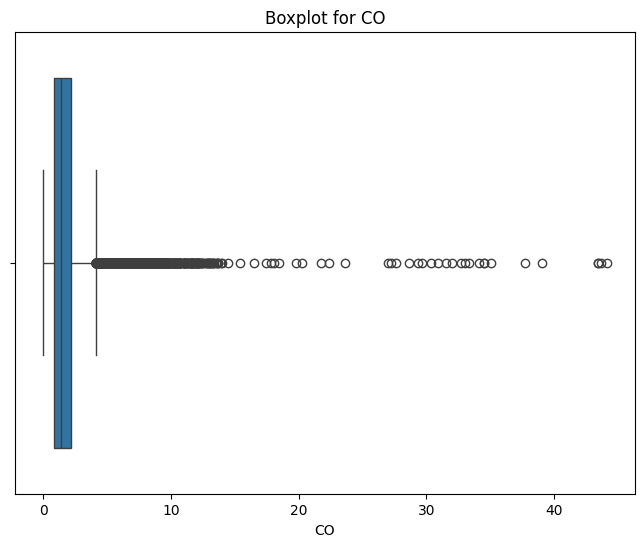

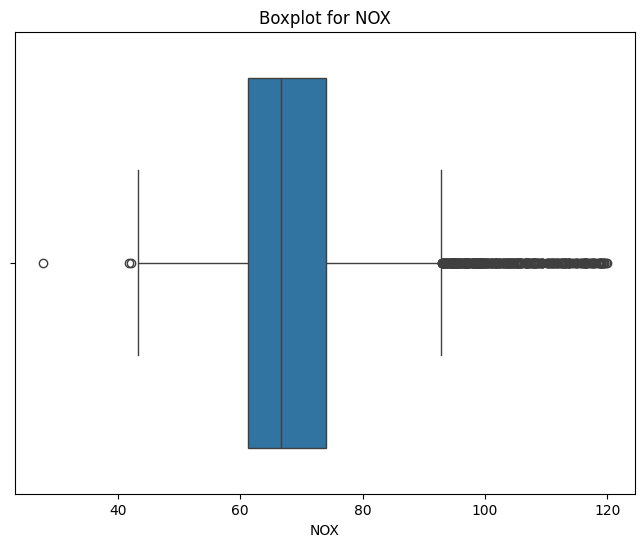

In [7]:
for column in df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=column, data=df)
    plt.title(f'Boxplot for {column}')
    plt.show()


In [8]:
def replace_outliers(data, colname):
    q1 = data[colname].quantile(0.25)
    q3 = data[colname].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + (1.5 * iqr)
    lower = q1 - (1.5 * iqr)

    outliers = (df[colname] < lower) | (df[colname] > upper)
    df[colname][outliers] = df[colname][outliers].apply(lambda x: upper if x > upper else lower)

# Replace outliers
columns_to_replace_outliers = ['AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP', 'CO', 'NOX']
for column in columns_to_replace_outliers:
    replace_outliers(df, column)

In [9]:
X = df[['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'CDP', 'CO', 'NOX']]
y = df['TEY']

In [10]:
# Splitting data with test and train
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [11]:
# Standardize the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Build a neural network model
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])


In [13]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [14]:
history = model.fit(X_train_scaled, y_train, epochs=25, validation_data=(X_val_scaled, y_val), verbose=2)

Epoch 1/25
329/329 - 2s - loss: 4953.9219 - val_loss: 304.4642 - 2s/epoch - 7ms/step
Epoch 2/25
329/329 - 1s - loss: 260.4522 - val_loss: 122.7888 - 672ms/epoch - 2ms/step
Epoch 3/25
329/329 - 1s - loss: 155.2990 - val_loss: 71.4877 - 608ms/epoch - 2ms/step
Epoch 4/25
329/329 - 1s - loss: 114.9667 - val_loss: 44.2163 - 597ms/epoch - 2ms/step
Epoch 5/25
329/329 - 1s - loss: 93.6688 - val_loss: 28.5617 - 671ms/epoch - 2ms/step
Epoch 6/25
329/329 - 1s - loss: 77.7453 - val_loss: 20.2846 - 596ms/epoch - 2ms/step
Epoch 7/25
329/329 - 1s - loss: 67.8624 - val_loss: 13.6815 - 675ms/epoch - 2ms/step
Epoch 8/25
329/329 - 1s - loss: 60.5377 - val_loss: 8.3124 - 605ms/epoch - 2ms/step
Epoch 9/25
329/329 - 1s - loss: 53.5056 - val_loss: 6.0730 - 658ms/epoch - 2ms/step
Epoch 10/25
329/329 - 1s - loss: 50.6560 - val_loss: 4.5554 - 608ms/epoch - 2ms/step
Epoch 11/25
329/329 - 1s - loss: 47.0676 - val_loss: 5.6465 - 625ms/epoch - 2ms/step
Epoch 12/25
329/329 - 1s - loss: 45.5051 - val_loss: 4.2803 - 6

In [15]:
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)

print('Mean Squared Error on Test Set:', mse)



71/71 [==============================] - 0s 1ms/step
Mean Squared Error on Test Set: 3.1687274145208595
